# Vacuum-Enhanced Air Gap Membrane Distillation (V-AGMD)
## Experimental Validation, Parametric Sensitivity Analysis, and Inverse Problem Estimation (Levenberg-Marquardt)

This notebook consolidates the entire analytical workflow:
1. **Master Experimental Dataset**: Loading real measured flow rates, inlet temperatures ($T_1, T_4$), vacuum pressure ($P_2$), and expanded uncertainties ($u_c$).
2. **C Numerical Solver Execution**: Interfacing with the high-performance PETSc C model (`vagmd0Dmodel`) with native permeate mass flow rate output in **g/min**.
3. **Formal Parametric Sensitivity Analysis**: Computing dimensionless relative elasticities ($E_\theta$), ranking critical parameters, and generating publication Tornado diagrams.
4. **Inverse Problem Resolution via Levenberg-Marquardt**: Quantifying hydrodynamically and thermally induced membrane deflection by estimating the effective air gap ($\delta_{g,\mathrm{eff}}$).
5. **Publication Figures (600 DPI, English)**: Generating parity plots, temperature validation, and parametric curves.


In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from IPython.display import Image, display

# Publication plot styling
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10


## 1. Loading Master Experimental Dataset (`Experimento_bancada_geral.csv`)

In [3]:
df_master = pd.read_csv('Experimento_bancada_geral.csv')
print(f'Total Experimental Cases: {len(df_master)}')
display(df_master[['Case', 'Real Flow (mL/min)', 'Feed temperature at the inlet (°C)', 'Coolant temperature at the inlet (°C)', 'Vacuum pressure (Pa)', 'Permeate mass flow rate (g/min)']].head(6))


Total Experimental Cases: 18


,Case,Real Flow (mL/min),Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Vacuum pressure (Pa),Permeate mass flow rate (g/min)
0,Case 1 (800 ml/min | 50°C),710.06,50.386643,30.692810,0,0.738695
1,Case 2 (800 ml/min | 80°C),710.06,81.398067,59.498787,0,1.436289
2,Case 3 (800 ml/min | 55°C),715.88,56.125973,35.693457,0,0.803663
3,Case 4 (800 ml/min | 60°C),716.71,61.113977,41.144604,0,0.958815
4,Case 5 (800 ml/min | 40°C),717.85,39.935562,20.127763,0,0.449922
5,Case 6 (800 ml/min | 45°C),720.44,45.966840,25.178093,0,0.534475


## 2. Parametric Sensitivity Ranking Table & Elasticity Analysis

In [4]:
df_sens = pd.read_csv('results/sensitivity_ranking.csv')
display(df_sens[['Rank', 'Parameter Label', 'Category', 'Nominal Value', 'Unit', 'Elasticity (Dimensionless)']])


,Rank,Parameter Label,Category,Nominal Value,Unit,Elasticity (Dimensionless)
0,1,"Feed inlet temperature ($T_{f,in}$)",Operating,5.566603e+01,°C,4.294772
1,2,"Coolant inlet temperature ($T_{c,in}$)",Operating,3.542789e+01,°C,-1.001848
2,3,Air gap thickness ($\delta_g$),Apparatus / Gap,2.000000e-03,m,-0.721101
3,4,Membrane porosity ($\varepsilon_m$),Membrane,7.000000e-01,-,0.173056
4,5,Membrane thickness ($\delta_m$),Membrane,1.500000e-04,m,-0.169963
5,6,Mean pore diameter ($d_p$),Membrane,3.500000e-07,m,0.059426
6,7,Coolant channel height ($h_c$),Apparatus / Module,2.000000e-03,m,-0.046861
7,8,Gap spacer porosity ($\varepsilon_g$),Apparatus / Gap,6.366203e-01,-,0.046150
8,9,Feed channel height ($h_f$),Apparatus / Module,2.000000e-03,m,-0.043164
9,10,Feed mass flow rate ($\dot{m}_f$),Operating,1.436266e-02,kg/s,0.033178


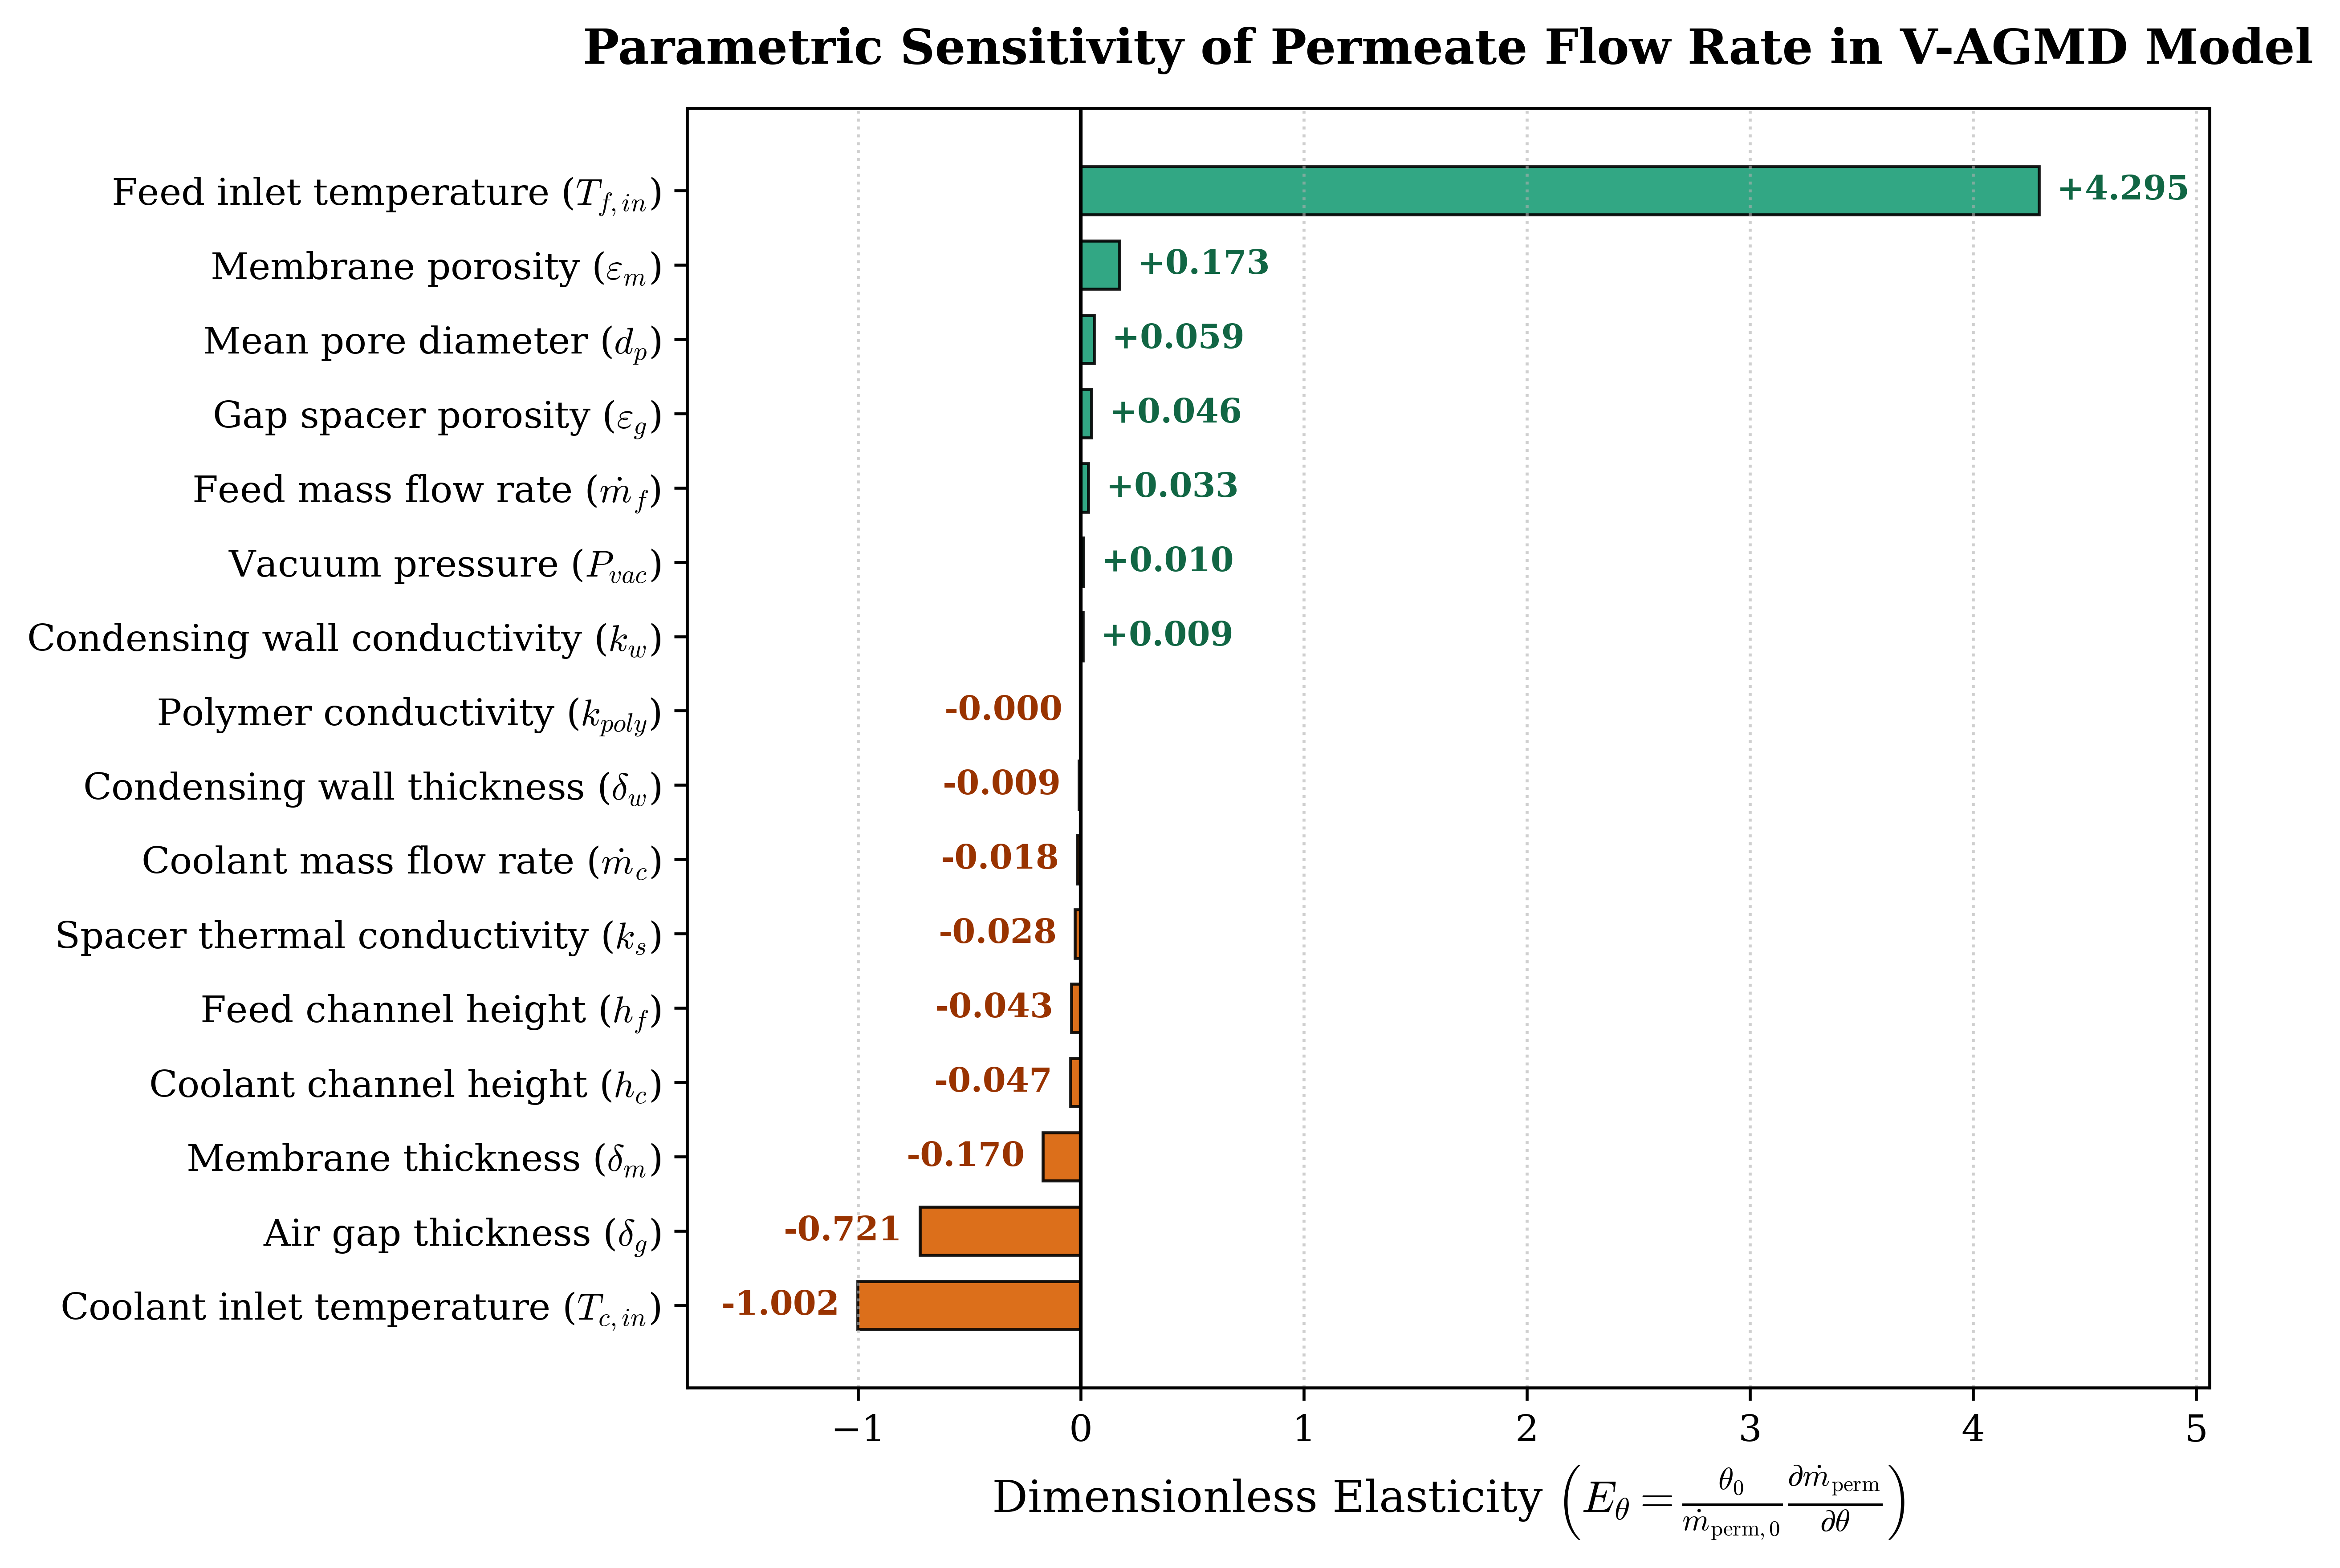

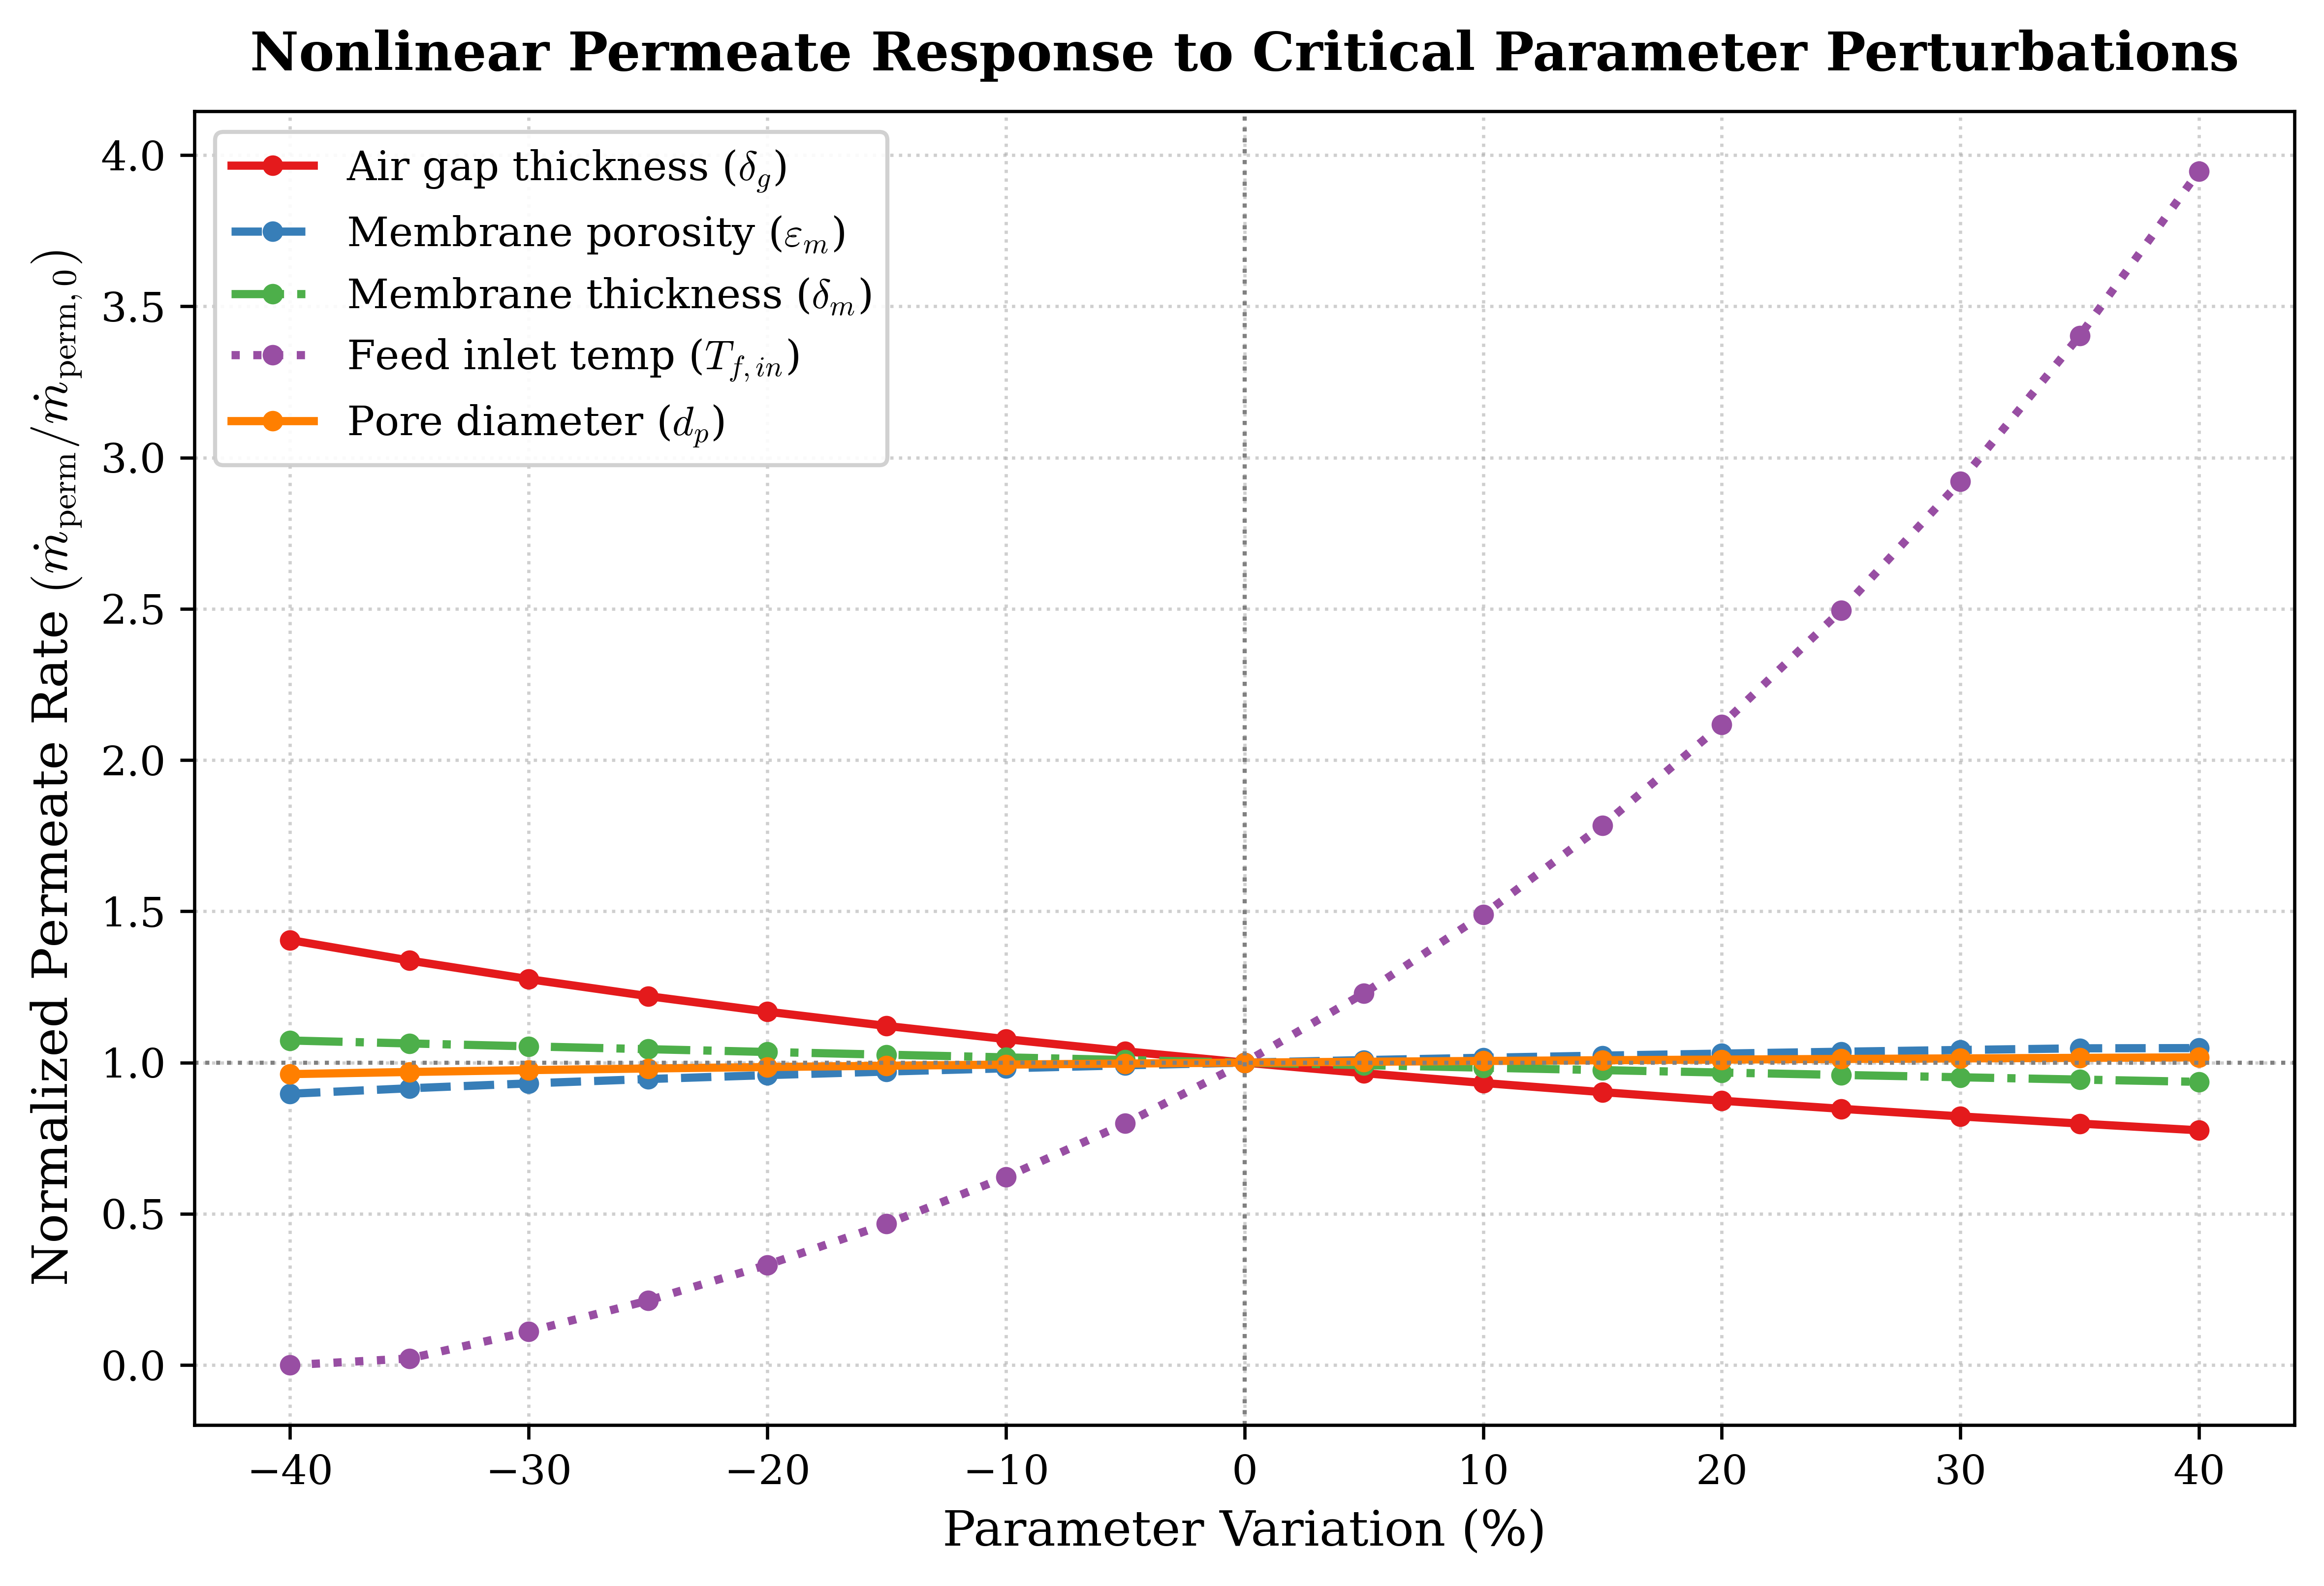

In [5]:
# Display Generated Tornado Diagram and Perturbation Curves
display(Image(filename='figures/tornado_sensitivity.png', width=700))
display(Image(filename='figures/parameter_perturbation_curves.png', width=700))


## 3. Levenberg-Marquardt Inverse Problem & Model Performance Metrics

In [6]:
df_metrics = pd.read_csv('results/model_performance_metrics.csv')
display(df_metrics)


,Model Configuration,RMSE (g/min),MAE (g/min),MAPE (%),Max Error (g/min),R²
0,Default Nominal Parameters (2.00 mm gap),4.703533e-01,4.434726e-01,5.113646e+01,7.225329e-01,-0.308751
1,Global LM Calibrated Gap (0.445 mm),2.962270e-01,1.730126e-01,1.507546e+01,1.012026e+00,0.480892
2,Flow-Dependent LM Calibrated Gaps,2.847049e-01,1.671966e-01,1.442679e+01,9.540102e-01,0.520489
3,Point-by-Point LM Calibrated (Deflection Model),9.771993e-09,4.472523e-09,5.733950e-07,2.990920e-08,1.000000


In [8]:
df_flow_gaps = pd.read_csv('results/flow_dependent_air_gaps.csv')
display(df_flow_gaps)


,Target Flow,Nominal Gap (mm),Effective Gap LM (mm),Reduction (%)
0,800 ml/min,2.0,0.496767,75.161647
1,1000 ml/min,2.0,0.432843,78.357855
2,1200 ml/min,2.0,0.430580,78.471011


## 4. Master Publication Figures (600 DPI)

In [ ]:
# 1. Permeate Parity Plot (Default vs Calibrated)
display(Image(filename='figures/fig1_parity_permeate_flow_rate.png', width=800))


In [ ]:
# 2. Outlet Temperatures Parity Plot
display(Image(filename='figures/fig2_parity_outlet_temperatures.png', width=550))


In [ ]:
# 3. Permeate Rate vs Real Feed Temperature Curves
display(Image(filename='figures/fig3_permeate_vs_temperature_flow_curves.png', width=650))


In [ ]:
# 4. Inferred Effective Air Gap Deflection Profile
display(Image(filename='figures/fig4_effective_air_gap_deflection.png', width=650))


In [ ]:
# 5. Composite 4-Panel Master Validation Figure
display(Image(filename='figures/fig5_master_validation_panel.png', width=900))
